## Symdiff × Assessor analysis

Two questions:
1. **Coverage** — how many LA-City parcels are absent from the symdiff dataset, and which neighborhoods are missing?
2. **Assessor time series by change_type** — do parcels that LARIAC classifies as structurally changed also show corresponding movement in the assessor record (SQFTmain, Units, UseCodeDescChar2)?

Change_type comes from `01_lariac_symdiff` (2014→2017 epoch).  
Assessor time series from `AssessorParcelsData_MultRolls.db` (RollYear 2006–2024).

In [5]:
import os, sqlite3
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

# os.chdir('../..')
print(f'Working directory: {os.getcwd()}')

SYMDIFF_PATH = 'data/04_results/lariac_symdiff_lacity.gpkg'
DB_PATH      = '/Users/adamswietek/Documents/PostDoc/data/raw_la/parcels/AssessorParcelsData_MultRolls.db'
MASTER_PATH  = 'data/processed/assessor_lariac.gpkg'
FIG_DIR      = 'notebooks/tasks/figures/'

EPOCH_LABEL  = '2014→2017'   # epoch whose change_type labels we use
LAYER_NAME   = 'symdiff_2014_2017'

# Ordered for legend clarity
CHANGE_ORDER = ['new_parcel', 'added_structure', 'extended',
                'no_change',
                'reduced', 'removed_structure', 'demolished']

CHANGE_COLORS = {
    'new_parcel':        '#1a9641',
    'added_structure':   '#a6d96a',
    'extended':          "#0344e6",
    'no_change':         '#888888',
    'reduced':           '#fdae61',
    'removed_structure': '#d7191c',
    'demolished':        '#7b0000',
}

Working directory: /Users/adamswietek/Documents/PostDoc/HiddenHousing


### 1. Load symdiff

In [6]:
symdiff = gpd.read_file(SYMDIFF_PATH, layer=LAYER_NAME,
                        columns=['AIN', 'change_type', 'neighborhood',
                                 'area_2014', 'area_2017', 'area_net',
                                 'n_2014', 'n_2017', 'n_delta',
                                 'shift_dx_m', 'shift_dy_m'])
symdiff['AIN'] = symdiff['AIN'].astype(str)
symdiff['neighborhood'] = 'Venice'  # hardcode for now since we're only analyzing one hood

print(f'Symdiff ({EPOCH_LABEL}): {len(symdiff):,} rows  |  '
      f'{symdiff["AIN"].nunique():,} unique AINs  |  '
      f'{symdiff["neighborhood"].nunique()} neighborhoods')
print('\nChange-type distribution:')
print(symdiff['change_type'].value_counts())

Symdiff (2014→2017): 632,159 rows  |  625,663 unique AINs  |  1 neighborhoods

Change-type distribution:
change_type
no_change            549696
extended              30197
reduced               17658
removed_structure     14245
added_structure       10076
demolished             6658
new_parcel             3629
Name: count, dtype: int64


<Axes: >

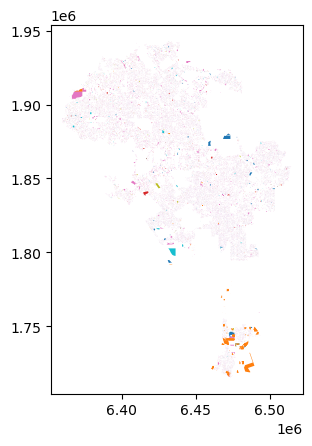

In [7]:
symdiff.sample(50_000).plot('change_type')

### 2. Coverage — missing parcels

In [8]:
from src.geoadmin import load_neighborhoods, load_cities

# Reference: 685k LA-City parcels from the 2017 master layer
parcel_ref = (
    gpd.read_file(MASTER_PATH, layer='2017', columns=['AIN'])
    .assign(AIN=lambda d: d['AIN'].astype(str))
    .drop_duplicates('AIN')
)
print(f'Parcel reference (2017 master): {len(parcel_ref):,} AINs')

symdiff_ains = set(symdiff['AIN'])
ref_ains     = set(parcel_ref['AIN'])

in_symdiff     = ref_ains & symdiff_ains
missing_ains   = ref_ains - symdiff_ains
extra_ains     = symdiff_ains - ref_ains  # symdiff AINs not in the 2017 master

print(f'\nIn both (matched):        {len(in_symdiff):>8,}  ({len(in_symdiff)/len(ref_ains)*100:.1f}% of ref)')
print(f'Missing from symdiff:     {len(missing_ains):>8,}  ({len(missing_ains)/len(ref_ains)*100:.1f}% of ref)')
print(f'In symdiff not in ref:    {len(extra_ains):>8,}  (AIN mismatch / new parcels)')

Parcel reference (2017 master): 1,452,636 AINs

In both (matched):         625,663  (43.1% of ref)
Missing from symdiff:      826,973  (56.9% of ref)
In symdiff not in ref:           0  (AIN mismatch / new parcels)


In [9]:
# Which neighborhoods are fully or partially missing?
# Load the neighborhoods used in the symdiff run
cities = load_cities().to_crs(4326)
hoods  = load_neighborhoods()
lacity = cities.query('CITYNAME_ALF == "LOS ANGELES"')

lacity_hood_names = set(
    gpd.sjoin(
        hoods.set_geometry(hoods.to_crs(4326).centroid).set_crs(4326),
        lacity[['geometry']],
        predicate='intersects'
    )['name'].tolist()
)
covered_hoods  = set(symdiff['neighborhood'].unique())
missing_hoods  = lacity_hood_names - covered_hoods

print(f'Total LA City neighborhoods: {len(lacity_hood_names)}')
print(f'Covered in symdiff:          {len(covered_hoods)}')
print(f'Missing (all topology errors): {len(missing_hoods)}')
print('\nMissing neighborhoods:')
for h in sorted(missing_hoods):
    print(f'  {h}')

Total LA City neighborhoods: 122
Covered in symdiff:          1
Missing (all topology errors): 121

Missing neighborhoods:
  Adams-Normandie
  Arleta
  Arlington Heights
  Atwater Village
  Baldwin Hills/Crenshaw
  Bel-Air
  Beverly Crest
  Beverly Grove
  Beverly Hills
  Beverlywood
  Boyle Heights
  Brentwood
  Broadway-Manchester
  Canoga Park
  Carthay
  Central-Alameda
  Century City
  Chatsworth
  Chatsworth Reservoir
  Chesterfield Square
  Cheviot Hills
  Chinatown
  Culver City
  Cypress Park
  Del Rey
  Downtown
  Eagle Rock
  East Hollywood
  Echo Park
  El Sereno
  Elysian Park
  Elysian Valley
  Encino
  Exposition Park
  Fairfax
  Florence
  Glassell Park
  Gramercy Park
  Granada Hills
  Green Meadows
  Griffith Park
  Hancock Park
  Hansen Dam
  Harbor City
  Harvard Heights
  Harvard Park
  Highland Park
  Historic South-Central
  Hollywood
  Hollywood Hills
  Hollywood Hills West
  Hyde Park
  Jefferson Park
  Koreatown
  Ladera Heights
  Lake Balboa
  Lake View Terra

In [21]:
# Per-neighborhood parcel coverage
symdiff_17 = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2017_2020',
                           columns=['AIN', 'change_type', 'neighborhood'])
symdiff_17['AIN'] = symdiff_17['AIN'].astype(str)
symdiff_17 = gpd.sjoin(symdiff_17, hoods.to_crs(symdiff.crs)[['name','geometry']], predicate='intersects', how='left').drop(columns=['index_right'])

symdiff_17['neighborhood'] = symdiff_17['name'].fillna('Unknown')
hood_coverage = (
    symdiff[['neighborhood', 'AIN']]
    .groupby('neighborhood')['AIN'].nunique()
    .rename('n_ains_2014_2017')
    .reset_index()
)
hood_coverage_17 = (
    symdiff_17[['neighborhood', 'AIN']]
    .groupby('neighborhood')['AIN'].nunique()
    .rename('n_ains_2017_2020')
    .reset_index()
)
hood_summary = hood_coverage.merge(hood_coverage_17, on='neighborhood', how='outer')

# Add missing hoods
missing_df = pd.DataFrame({'neighborhood': list(missing_hoods),
                           'n_ains_2014_2017': 0,
                           'n_ains_2017_2020': 0})
hood_summary = pd.concat([hood_summary, missing_df], ignore_index=True).fillna(0)
hood_summary['any_missing'] = (hood_summary['n_ains_2014_2017'] == 0) | (hood_summary['n_ains_2017_2020'] == 0)

print('Neighborhoods with zero coverage in either epoch:')
print(hood_summary[hood_summary['any_missing']].to_string(index=False))

Neighborhoods with zero coverage in either epoch:
                         neighborhood  n_ains_2014_2017  n_ains_2017_2020  any_missing
                      Adams-Normandie               0.0              1919         True
                             Alhambra               0.0                72         True
                               Arleta               0.0              6740         True
                    Arlington Heights               0.0              2244         True
                      Atwater Village               0.0              3372         True
               Baldwin Hills/Crenshaw               0.0              3965         True
                              Bel-Air               0.0              3058         True
                        Beverly Crest               0.0              4468         True
                        Beverly Grove               0.0              4136         True
                        Beverly Hills               0.0              1432       

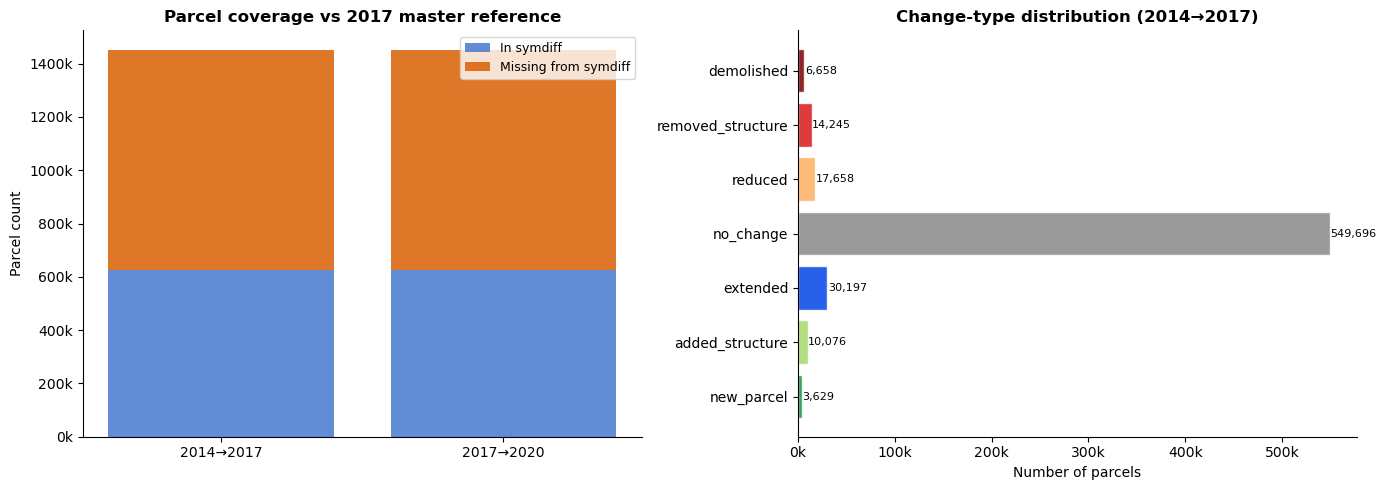

In [22]:
# --- Coverage summary figure ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor='white')

# Left: stacked bar — matched vs missing by epoch
ax = axes[0]
symdiff_17_ains = set(symdiff_17['AIN'])
epochs = ['2014→2017', '2017→2020']
matched = [len(ref_ains & symdiff_ains), len(ref_ains & symdiff_17_ains)]
missing = [len(ref_ains) - m for m in matched]

x = np.arange(len(epochs))
ax.bar(x, matched, color='#4878d0', label='In symdiff', alpha=0.85)
ax.bar(x, missing, bottom=matched, color='#d95f02', label='Missing from symdiff', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(epochs)
ax.set_ylabel('Parcel count')
ax.set_title('Parcel coverage vs 2017 master reference', fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)

# Right: distribution of symdiff change_types
ax2 = axes[1]
ct_counts = symdiff['change_type'].value_counts().reindex(CHANGE_ORDER).dropna()
colors = [CHANGE_COLORS[ct] for ct in ct_counts.index]
bars = ax2.barh(ct_counts.index, ct_counts.values, color=colors, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, ct_counts.values):
    ax2.text(bar.get_width() + 500, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=8)
ax2.set_xlabel('Number of parcels')
ax2.set_title(f'Change-type distribution ({EPOCH_LABEL})', fontweight='bold')
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v/1e3:.0f}k'))
ax2.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}symdiff_coverage_summary.png', dpi=150, bbox_inches='tight')
plt.show()

### 2a. Coverage diagnostics — root causes

Three root causes explain the symdiff gap:

| # | Cause | Fixable? |
|---|-------|----------|
| A | **LARIAC4 AIN asymmetry** — 2014 uses county-wide AINs; buildings outside LA City parcel_ref appear as false demolished in 2014→2017 | ✅ fixed in pipeline |
| B | **Topology exceptions** — `TopologyException` from invalid LARIAC geometries; whole neighborhood silently dropped | ✅ fixed in pipeline |
| C | **Vacant / no-building parcels** — parking lots, vacant land; no LARIAC footprint in any year | ❌ expected |

In [12]:
s14_17

,AIN,area_2014,area_2017,n_2014,n_2017,area_net,n_delta,epoch,neighborhood,shift_dx_m,shift_dy_m,change_type,area_2020,n_2020,geometry
0,,6641.363550,0.000000,36.0,0,-6641.363550,-36,2014→2017,El Sereno,1.092,-0.551,demolished,NaN,NaN,None
1,4031001033,143.529770,0.000000,1.0,0,-143.529770,-1,2014→2017,El Sereno,1.092,-0.551,demolished,NaN,NaN,None
2,4031026004,30.942343,0.000000,1.0,0,-30.942343,-1,2014→2017,El Sereno,1.092,-0.551,demolished,NaN,NaN,None
3,4033002013,91.774633,0.000000,1.0,0,-91.774633,-1,2014→2017,El Sereno,1.092,-0.551,demolished,NaN,NaN,None
4,4033018021,277.128050,0.000000,1.0,0,-277.128050,-1,2014→2017,El Sereno,1.092,-0.551,demolished,NaN,NaN,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427132,2727021020,4163.749720,4163.748677,1.0,1,-5.469732,0,2014→2017,Chatsworth Reservoir,-5.606,2.485,reduced,NaN,NaN,"MULTIPOLYGON (((6378478.041 1909236.382, 63784..."
427133,2727021022,868.798944,728.813293,1.0,1,-139.677848,0,2014→2017,Chatsworth Reservoir,-5.606,2.485,reduced,NaN,NaN,"MULTIPOLYGON (((6376524.882 1909950.121, 63771..."
427134,2727021024,1594.600170,193.668744,5.0,2,-1400.390884,-3,2014→2017,Chatsworth Reservoir,-5.606,2.485,removed_structure,NaN,NaN,"MULTIPOLYGON (((6378531.434 1908646.998, 63785..."
427135,2746013033,1107.999358,1108.000167,1.0,1,-0.546739,0,2014→2017,Chatsworth Reservoir,-5.606,2.485,no_change,NaN,NaN,"MULTIPOLYGON (((6378534.238 1909055.42, 637854..."


Top neighborhoods by demolished count (2014→2017):
               label  n_demolished  n_total  demo_pct
              Sylmar           184    12611  1.459044
           El Sereno           160     8241  1.941512
          Chatsworth           138     9932  1.389448
Hollywood Hills West           127     6715  1.891288
      Woodland Hills           122    17077  0.714411
            Mid-City           122     9331  1.307470
         Westchester           121    10293  1.175556
     North Hollywood           116    10281  1.128295
      West Hollywood           111     1343  8.265078
           Brentwood           109     7275  1.498282
   Pacific Palisades           106     8105  1.307835
          Sun Valley           106    13231  0.801149
        Sherman Oaks           104    13809  0.753132
       Beverly Hills           101     1430  7.062937
       Boyle Heights           100    10435  0.958313
             Pacoima            98    10299  0.951549
         Studio City           

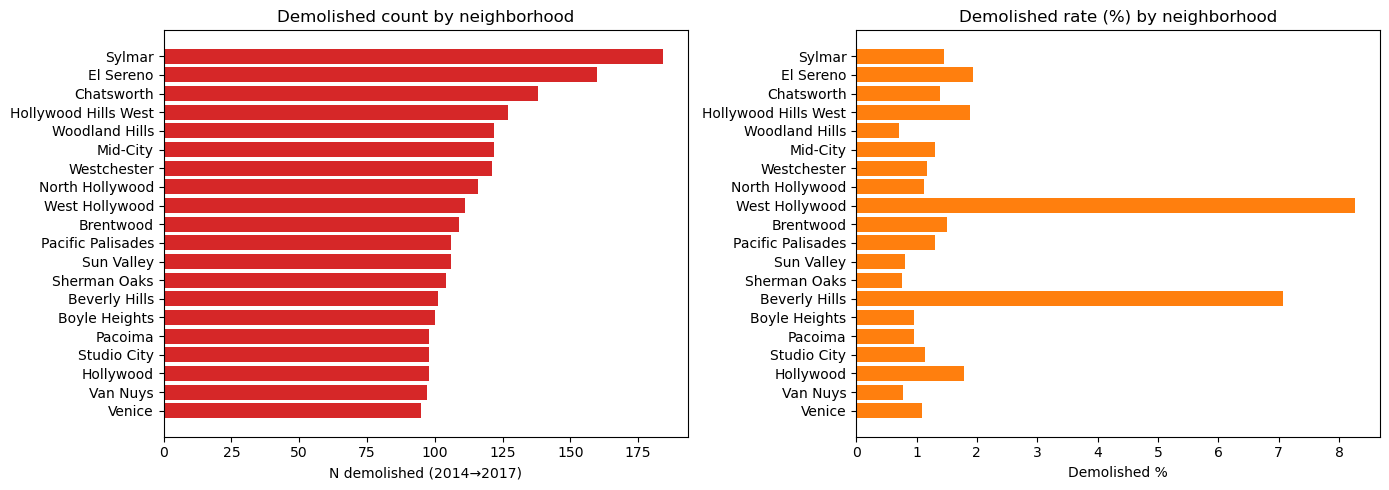

Total demolished 2014→2017: 6,658


In [23]:
# T-4a  False demolished by neighborhood (LARIAC4 AIN asymmetry)
# Strategy: in the fixed pipeline demolished should only appear where a building
# genuinely disappeared. The old pipeline inflated demolished for neighborhoods
# like Beverly Hills, West Hollywood, and Culver City whose centroids fall
# inside LA City but whose parcels live outside the LA City parcel_ref.
#
# We estimate the false-demolished count using the CURRENT (fixed) output:
# neighborhoods that have a suspiciously high demolished rate relative to
# their parcel count are flagged.

s14_17 = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2014_2017')

demo_by_hood = (
    s14_17[s14_17['change_type'] == 'demolished']
    .groupby('label')['AIN']
    .count()
    .rename('n_demolished')
    .reset_index()
)
total_by_hood = (
    s14_17.groupby('label')['AIN']
    .count()
    .rename('n_total')
    .reset_index()
)
demo_rate = demo_by_hood.merge(total_by_hood, on='label')
demo_rate['demo_pct'] = demo_rate['n_demolished'] / demo_rate['n_total'] * 100
demo_rate = demo_rate.sort_values('n_demolished', ascending=False)

print('Top neighborhoods by demolished count (2014→2017):')
print(demo_rate.head(20).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top20 = demo_rate.head(20)
axes[0].barh(top20['label'], top20['n_demolished'], color='#d62728')
axes[0].set_xlabel('N demolished (2014→2017)')
axes[0].set_title('Demolished count by neighborhood')
axes[0].invert_yaxis()

axes[1].barh(top20['label'], top20['demo_pct'], color='#ff7f0e')
axes[1].set_xlabel('Demolished %')
axes[1].set_title('Demolished rate (%) by neighborhood')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
print(f'Total demolished 2014→2017: {s14_17[s14_17["change_type"]=="demolished"].shape[0]:,}')

In [27]:
# T-4b  Topology-error neighborhoods — neighborhoods missing from one or both epochs
# A neighborhood that silently fails the difference() step will appear in one epoch
# but not the other, or be entirely absent from the symdiff output.

from src.geoadmin import load_neighborhoods, load_cities
cities = load_cities().to_crs(4326)
hoods  = load_neighborhoods()
lacity = cities.query('CITYNAME_ALF == "LOS ANGELES"')

hoods_lacity_gdf = gpd.sjoin(
    hoods.set_geometry(hoods.to_crs(4326).centroid).set_crs(4326),
    lacity[['geometry']],
    predicate='intersects'
)
all_hoods = set(hoods_lacity_gdf['name'])

s17_20 = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2017_2020')
s14_17 = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2014_2017')

hoods_1417 = set(s14_17['label'].unique())
hoods_1720 = set(s17_20['label'].unique())

missing_1417 = all_hoods - hoods_1417
missing_1720 = all_hoods - hoods_1720
missing_both = missing_1417 & missing_1720
missing_either = missing_1417 | missing_1720

print(f'Total neighborhoods in reference:         {len(all_hoods):>4}')
print(f'Neighborhoods in 2014→2017 output:        {len(hoods_1417):>4}')
print(f'Neighborhoods in 2017→2020 output:        {len(hoods_1720):>4}')
print(f'Missing from 2014→2017:                   {len(missing_1417):>4}')
print(f'Missing from 2017→2020:                   {len(missing_1720):>4}')
print(f'Missing from both epochs:                 {len(missing_both):>4}')
print(f'Missing from at least one epoch:          {len(missing_either):>4}')
print()
print('Missing from 2014→2017:')
print(sorted(missing_1417))
print()
print('Missing from 2017→2020:')
print(sorted(missing_1720))

Total neighborhoods in reference:          122
Neighborhoods in 2014→2017 output:         122
Neighborhoods in 2017→2020 output:         122
Missing from 2014→2017:                      0
Missing from 2017→2020:                      0
Missing from both epochs:                    0
Missing from at least one epoch:             0

Missing from 2014→2017:
[]

Missing from 2017→2020:
[]


In [28]:
# T-4c  Vacant / no-building parcel estimate
# Parcels in parcel_ref that have no LARIAC footprint in either epoch are
# legitimately absent from the symdiff — they are parking lots, vacant land,
# roads, etc. This is the irreducible gap that cannot be fixed by the pipeline.

# The symdiff covers only parcels that had a building in at least one epoch.
# Parcels absent from both epochs are the 'vacant' category.

s14_17 = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2014_2017')
s17_20 = gpd.read_file(SYMDIFF_PATH, layer='symdiff_2017_2020')

# All unique AINs ever seen in symdiff
all_symdiff_ains = set(s14_17['AIN'].unique()) | set(s17_20['AIN'].unique())

n_ref   = len(parcel_ref)
n_match = len(set(parcel_ref['AIN'].astype(str)) & all_symdiff_ains)
n_miss  = n_ref - n_match

# Use assessor UseType to estimate how many missing parcels are genuinely vacant
con = sqlite3.connect(DB_PATH)
vacant_q = """
    SELECT AIN, UseType, UseCodeDescChar2
    FROM assessor
    WHERE RollYear = 2017
    AND UseType IN ('Vacant Land', 'Misc', 'Recreational')
"""
vacant_assr = pd.read_sql(vacant_q, con)
con.close()

vacant_ains = set(vacant_assr['AIN'].astype(str))
missing_ains = set(parcel_ref['AIN'].astype(str)) - all_symdiff_ains
n_vacant_missing = len(missing_ains & vacant_ains)
n_unknown_missing = len(missing_ains) - n_vacant_missing

print('Parcel coverage breakdown:')
print(f'  Total LA City parcels (parcel_ref):     {n_ref:>8,}')
print(f'  Parcels in symdiff (any epoch):         {n_match:>8,}  ({n_match/n_ref*100:.1f}%)')
print(f'  Parcels missing from symdiff:           {n_miss:>8,}  ({n_miss/n_ref*100:.1f}%)')
print(f'    of which vacant/misc (assessor):      {n_vacant_missing:>8,}  ({n_vacant_missing/n_miss*100:.1f}% of missing)')
print(f'    other/unexplained missing:            {n_unknown_missing:>8,}  ({n_unknown_missing/n_miss*100:.1f}% of missing)')
print()

# UseType breakdown for missing parcels that have assessor records
con = sqlite3.connect(DB_PATH)
all_missing_q = f"""
    SELECT AIN, UseType, UseCodeDescChar2
    FROM assessor
    WHERE RollYear = 2017
    AND AIN IN ({','.join(['?']*min(len(missing_ains),5000))})
"""
missing_sample = list(missing_ains)[:5000]
missing_assr = pd.read_sql(all_missing_q, con, params=missing_sample)
con.close()

usetype_breakdown = (
    missing_assr.groupby('UseType')['AIN']
    .count()
    .sort_values(ascending=False)
    .head(10)
)
print('UseType breakdown for sample of missing parcels (2017 assessor roll):')
print(usetype_breakdown.to_string())

DatabaseError: Execution failed on sql '
    SELECT AIN, UseType, UseCodeDescChar2
    FROM assessor
    WHERE RollYear = 2017
    AND UseType IN ('Vacant Land', 'Misc', 'Recreational')
': no such table: assessor

### 3. Load assessor time series for symdiff AINs

Query the SQLite DB for all roll years, joining only against a stratified random sample of AINs from each `change_type`.  
Uses a temp table to avoid a massive `IN` clause and keeps the remainder of the notebook interactive.

In [31]:
# Stratified sample by LARIAC change_type so the assessor time-series query
# stays small enough for interactive analysis.
SAMPLE_AINS_PER_CHANGE_TYPE = 5_000
RANDOM_SEED = 42

# Keep the full symdiff available so re-running this cell does not repeatedly
# down-sample an already sampled frame.
if 'symdiff_full' not in globals():
    symdiff_full = symdiff.copy()

ain_change_type = symdiff_full[['AIN', 'change_type']].drop_duplicates('AIN').copy()

sampled_parts = []
for change_type in CHANGE_ORDER:
    group = ain_change_type[ain_change_type['change_type'] == change_type]
    if group.empty:
        continue
    sampled_parts.append(
        group.sample(n=min(len(group), SAMPLE_AINS_PER_CHANGE_TYPE), random_state=RANDOM_SEED)
    )

# Include any unexpected change_type labels without breaking downstream plots.
for change_type, group in ain_change_type[~ain_change_type['change_type'].isin(CHANGE_ORDER)].groupby('change_type'):
    sampled_parts.append(
        group.sample(n=min(len(group), SAMPLE_AINS_PER_CHANGE_TYPE), random_state=RANDOM_SEED)
    )

sampled_ain_change_type = pd.concat(sampled_parts, ignore_index=True)

ain_list = sampled_ain_change_type['AIN'].astype(str).tolist()
symdiff = symdiff_full[symdiff_full['AIN'].isin(ain_list)].copy()

print('Sampled AINs by change_type:')
print(sampled_ain_change_type['change_type'].value_counts().reindex(CHANGE_ORDER).dropna().astype(int))
print(f'Querying assessor DB for {len(ain_list):,} sampled AINs across all roll years…')

conn = sqlite3.connect(DB_PATH)
conn.execute('CREATE TEMP TABLE _symdiff_ains (AIN TEXT PRIMARY KEY)')
conn.executemany('INSERT OR IGNORE INTO _symdiff_ains VALUES (?)', [(a,) for a in ain_list])

assr = pd.read_sql(
    '''
    SELECT p.AIN, p.RollYear, p.SQFTmain, p.Units, p.UseCodeDescChar2,
           p.Roll_ImpValue, p.Roll_LandValue, p.UseType
    FROM   parcels p
    JOIN   _symdiff_ains s ON p.AIN = s.AIN
    ''',
    conn
)
conn.close()

assr['AIN'] = assr['AIN'].astype(str)
print(f'Loaded {len(assr):,} assessor rows  |  '
      f'{assr["AIN"].nunique():,} unique AINs  |  '
      f'RollYears: {sorted(assr["RollYear"].unique())}')

Loaded 587,161 assessor rows  |  32,091 unique AINs  |  RollYears: [np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]


In [32]:
# Merge change_type onto assessor records
ct_map = symdiff[['AIN', 'change_type']].drop_duplicates('AIN').set_index('AIN')['change_type']
assr['change_type'] = assr['AIN'].map(ct_map)

print('Assessor rows by change_type:')
print(assr['change_type'].value_counts())
print(f'\nUnmatched (AIN in assessor but not symdiff): {assr["change_type"].isna().sum():,}')

Assessor rows by change_type:
change_type
no_change            94645
reduced              94458
extended             94357
removed_structure    93918
added_structure      93274
demolished           63455
new_parcel           53054
Name: count, dtype: int64

Unmatched (AIN in assessor but not symdiff): 0


### 4. Year-over-year change rates by change_type

For each parcel, flag whether a given feature changed from the prior roll year.  
Then compute: for each change_type group, what % of parcels had a change in each year?

In [33]:
def yoy_change_rate(df, feature, change_type_col='change_type'):
    """
    Returns a DataFrame: (RollYear, change_type) → % of AINs in that group
    with a year-over-year change in `feature`.
    """
    d = df.sort_values(['AIN', 'RollYear']).copy()
    d[feature] = pd.to_numeric(d[feature], errors='coerce')
    d['prev']  = d.groupby('AIN')[feature].shift(1)
    d['changed'] = (d[feature] != d['prev']) & d['prev'].notna()

    # Total AINs per group (denominator)
    totals = d.groupby(change_type_col)['AIN'].nunique().rename('n_total')

    # Changes per (year, group)
    counts = (
        d[d['changed']]
        .groupby(['RollYear', change_type_col])
        .size()
        .reset_index(name='n_changed')
    )
    counts = counts.join(totals, on=change_type_col)
    counts['pct'] = counts['n_changed'] / counts['n_total'] * 100
    return counts

assr_valid = assr[assr['change_type'].notna()].copy()

rates_sqft  = yoy_change_rate(assr_valid, 'SQFTmain')
rates_units = yoy_change_rate(assr_valid, 'Units')
rates_impv  = yoy_change_rate(assr_valid, 'Roll_ImpValue')

print('Change rate data shapes:')
for name, df in [('SQFTmain', rates_sqft), ('Units', rates_units), ('Roll_ImpValue', rates_impv)]:
    print(f'  {name}: {len(df)} rows')

Change rate data shapes:
  SQFTmain: 126 rows
  Units: 126 rows
  Roll_ImpValue: 126 rows


### 5. Main plot — assessor change rates over time, by symdiff change_type

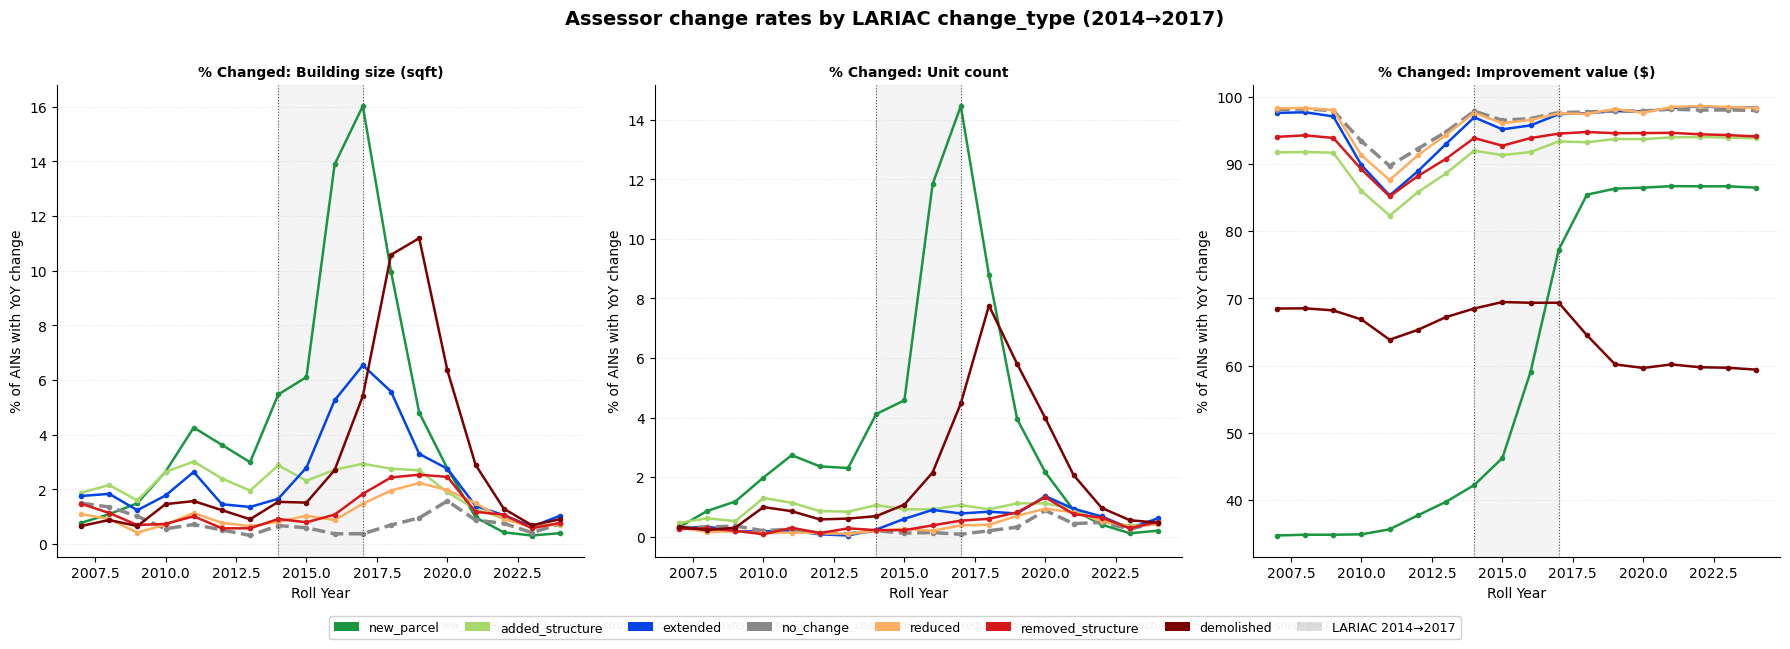

In [34]:
FEATURES = [
    ('SQFTmain',      'Building size (sqft)',     rates_sqft),
    ('Units',         'Unit count',               rates_units),
    ('Roll_ImpValue', 'Improvement value ($)',     rates_impv),
]

# Only plot change_types with enough observations
MIN_AINS = 200
totals = assr_valid.groupby('change_type')['AIN'].nunique()
plot_types = [ct for ct in CHANGE_ORDER if totals.get(ct, 0) >= MIN_AINS]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')

for ax, (feat, label, rates) in zip(axes, FEATURES):
    for ct in plot_types:
        sub = rates[rates['change_type'] == ct].sort_values('RollYear')
        if sub.empty:
            continue
        lw  = 2.5 if ct == 'no_change' else 1.8
        ls  = '--' if ct == 'no_change' else '-'
        ax.plot(sub['RollYear'], sub['pct'],
                color=CHANGE_COLORS[ct], lw=lw, ls=ls,
                marker='o', markersize=3, label=ct)

    # Shade the LARIAC 2014→2017 epoch
    ax.axvspan(2014, 2017, color='#aaaaaa', alpha=0.12, label='LARIAC epoch')
    ax.axvline(2014, color='#555', lw=0.8, ls=':')
    ax.axvline(2017, color='#555', lw=0.8, ls=':')

    ax.set_title(f'% Changed: {label}', fontweight='bold', fontsize=10)
    ax.set_ylabel('% of AINs with YoY change')
    ax.set_xlabel('Roll Year')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

# Shared legend
handles = [mpatches.Patch(facecolor=CHANGE_COLORS[ct], label=ct) for ct in plot_types]
handles.append(mpatches.Patch(facecolor='#aaaaaa', alpha=0.4, label='LARIAC 2014→2017'))
fig.legend(handles=handles, loc='lower center', ncol=len(handles),
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.05))

n_per_ct = totals[plot_types].to_dict()
subtitle  = '  |  '.join(f'{ct}: n={n:,}' for ct, n in n_per_ct.items())
fig.text(0.5, -0.02, subtitle, ha='center', fontsize=7.5, color='#555', style='italic')

plt.suptitle(f'Assessor change rates by LARIAC change_type ({EPOCH_LABEL})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}symdiff_assr_change_rates.png', dpi=150, bbox_inches='tight')
plt.show()

### 6. Level plot — median SQFTmain and Units over time by change_type

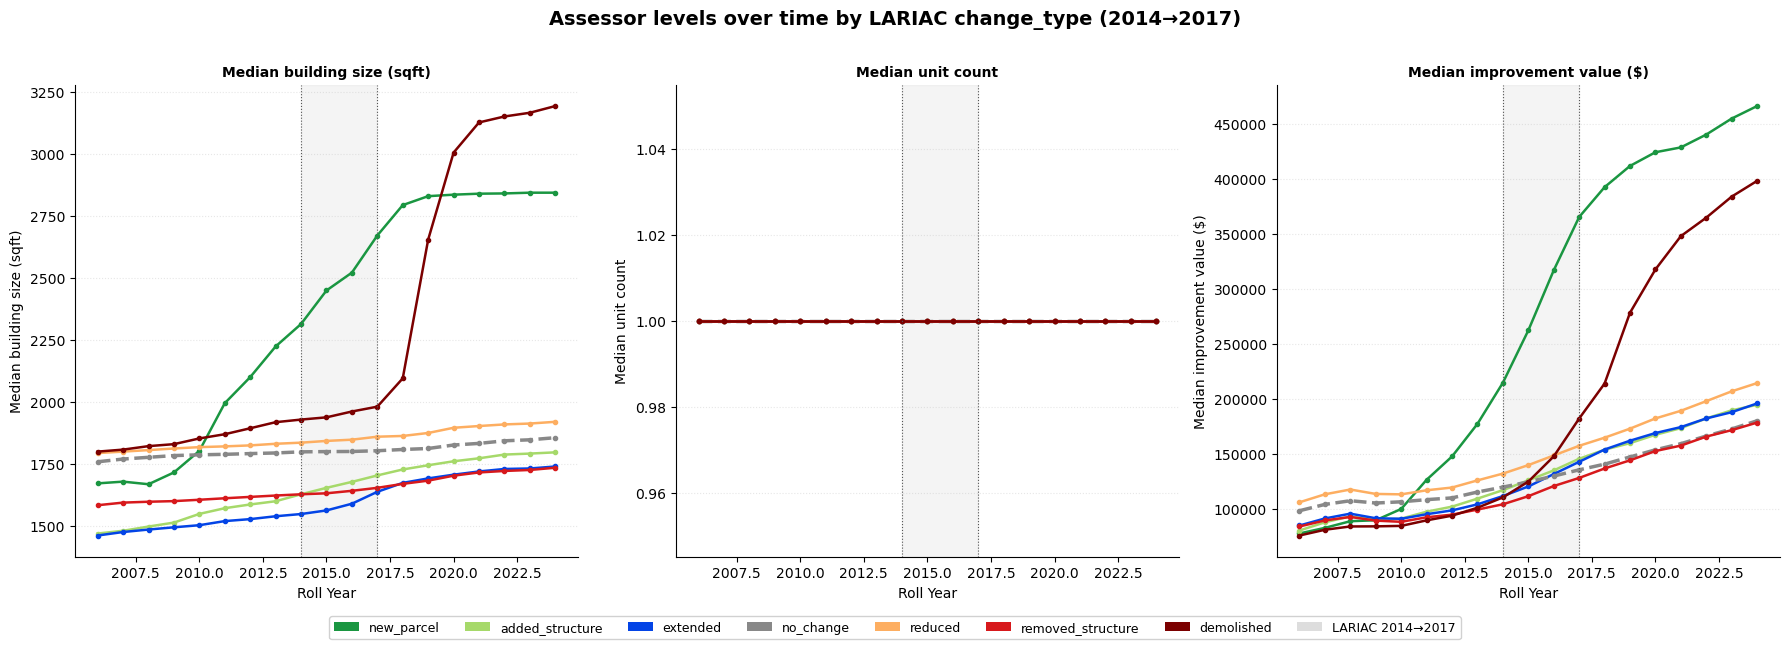

In [35]:
LEVEL_FEATURES = [
    ('SQFTmain',      'Median building size (sqft)'),
    ('Units',         'Median unit count'),
    ('Roll_ImpValue', 'Median improvement value ($)'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), facecolor='white')

for ax, (feat, label) in zip(axes, LEVEL_FEATURES):
    d = assr_valid[assr_valid['change_type'].isin(plot_types)].copy()
    d[feat] = pd.to_numeric(d[feat], errors='coerce')
    d = d[d[feat] > 0]

    medians = (
        d.groupby(['RollYear', 'change_type'])[feat]
        .median()
        .reset_index()
    )

    for ct in plot_types:
        sub = medians[medians['change_type'] == ct].sort_values('RollYear')
        if sub.empty:
            continue
        lw = 2.5 if ct == 'no_change' else 1.8
        ls = '--' if ct == 'no_change' else '-'
        ax.plot(sub['RollYear'], sub[feat],
                color=CHANGE_COLORS[ct], lw=lw, ls=ls,
                marker='o', markersize=3, label=ct)

    ax.axvspan(2014, 2017, color='#aaaaaa', alpha=0.12)
    ax.axvline(2014, color='#555', lw=0.8, ls=':')
    ax.axvline(2017, color='#555', lw=0.8, ls=':')
    ax.set_title(label, fontweight='bold', fontsize=10)
    ax.set_ylabel(label)
    ax.set_xlabel('Roll Year')
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', ls=':', alpha=0.3)

handles = [mpatches.Patch(facecolor=CHANGE_COLORS[ct], label=ct) for ct in plot_types]
handles.append(mpatches.Patch(facecolor='#aaaaaa', alpha=0.4, label='LARIAC 2014→2017'))
fig.legend(handles=handles, loc='lower center', ncol=len(handles),
           fontsize=9, framealpha=0.9, bbox_to_anchor=(0.5, -0.05))

plt.suptitle(f'Assessor levels over time by LARIAC change_type ({EPOCH_LABEL})',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}symdiff_assr_levels.png', dpi=150, bbox_inches='tight')
plt.show()

### 7. SQFTmain change magnitude by change_type

Among parcels that changed SQFTmain during the LARIAC epoch (2014-2017),
what is the distribution of the change in sqft?

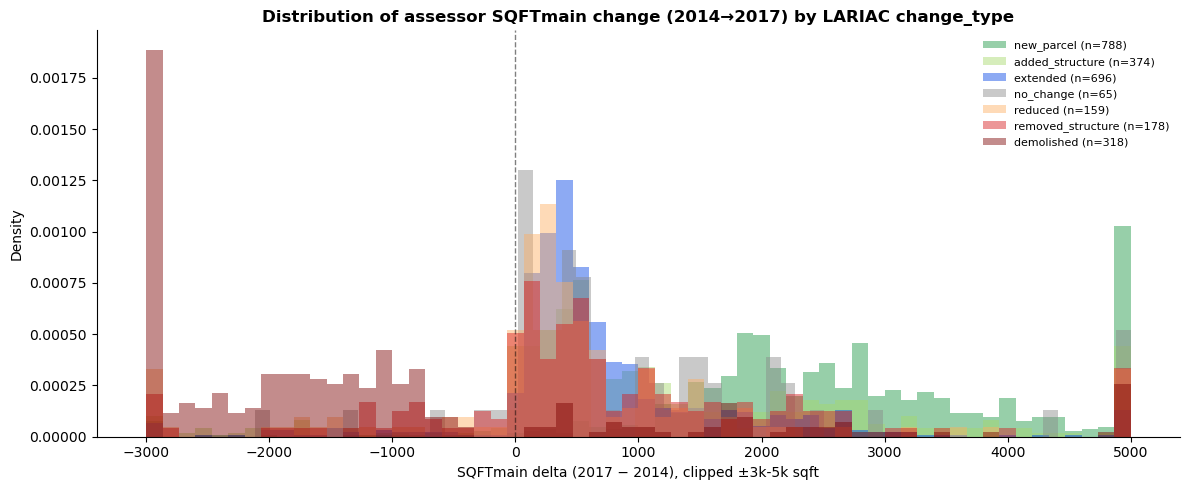


SQFTmain delta summary (2014→2017 assessor):
                      n  pct_changed  median    mean  p25     p75
change_type                                                      
new_parcel         2567         30.7     0.0  2015.3  0.0  1680.5
added_structure    4912          7.6     0.0   320.5  0.0     0.0
extended           4974         14.0     0.0   205.1  0.0     0.0
no_change          4997          1.3     0.0    19.7  0.0     0.0
reduced            4974          3.2     0.0    43.6  0.0     0.0
removed_structure  4957          3.6     0.0    48.8  0.0     0.0
demolished         3444          9.2     0.0   -60.9  0.0     0.0


In [36]:
d_sorted = assr_valid.sort_values(['AIN', 'RollYear']).copy()
d_sorted['SQFTmain'] = pd.to_numeric(d_sorted['SQFTmain'], errors='coerce')

# Compute 2014→2017 delta for each AIN
sqft_14 = d_sorted[d_sorted['RollYear'] == 2014][['AIN', 'SQFTmain']].set_index('AIN')['SQFTmain'].rename('sqft_2014')
sqft_17 = d_sorted[d_sorted['RollYear'] == 2017][['AIN', 'SQFTmain']].set_index('AIN')['SQFTmain'].rename('sqft_2017')

sqft_delta = pd.concat([sqft_14, sqft_17], axis=1).dropna()
sqft_delta['delta'] = sqft_delta['sqft_2017'] - sqft_delta['sqft_2014']
sqft_delta['change_type'] = sqft_delta.index.map(ct_map)

fig, ax = plt.subplots(figsize=(12, 5), facecolor='white')

for ct in plot_types:
    vals = sqft_delta.loc[(sqft_delta['change_type'] == ct) & (sqft_delta['delta'] != 0), 'delta']
    vals = vals.clip(-3000, 5000)  # clip extreme outliers for readability
    if vals.empty:
        continue
    ax.hist(vals, bins=60, density=True, alpha=0.45,
            color=CHANGE_COLORS[ct], label=f'{ct} (n={len(vals):,})',
            histtype='stepfilled', edgecolor='none')

ax.axvline(0, color='black', lw=1, ls='--', alpha=0.5)
ax.set_xlabel('SQFTmain delta (2017 − 2014), clipped ±3k-5k sqft')
ax.set_ylabel('Density')
ax.set_title('Distribution of assessor SQFTmain change (2014→2017) by LARIAC change_type',
             fontweight='bold')
ax.legend(fontsize=8, frameon=False)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(f'{FIG_DIR}symdiff_sqft_delta_dist.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table
summary = (
    sqft_delta[sqft_delta['change_type'].isin(plot_types)]
    .groupby('change_type')['delta']
    .agg(n='count', pct_changed=lambda x: (x != 0).mean() * 100,
         median='median', mean='mean', p25=lambda x: x.quantile(0.25),
         p75=lambda x: x.quantile(0.75))
    .reindex(plot_types)
    .round(1)
)
print('\nSQFTmain delta summary (2014→2017 assessor):')
print(summary.to_string())

### 8. Concordance check — does LARIAC change_type predict assessor SQFTmain change?

For each change_type, what fraction of parcels show *any* assessor SQFTmain change between 2014 and 2017?

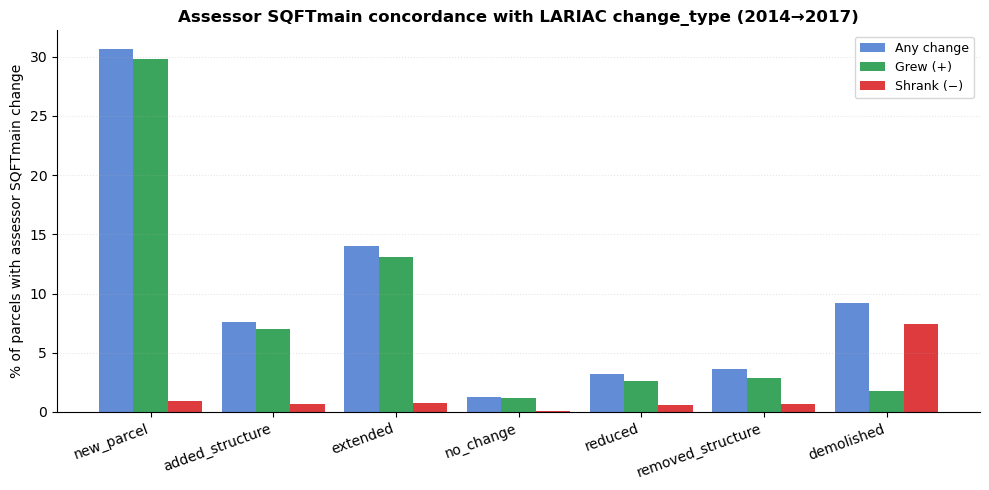

                   assr_changed  assr_grew  assr_shrank
change_type                                            
new_parcel                 30.7       29.8          0.9
added_structure             7.6        7.0          0.7
extended                   14.0       13.1          0.8
no_change                   1.3        1.2          0.1
reduced                     3.2        2.6          0.6
removed_structure           3.6        2.9          0.7
demolished                  9.2        1.8          7.4


In [37]:
concordance = (
    sqft_delta[sqft_delta['change_type'].isin(plot_types)]
    .assign(assr_changed=lambda d: d['delta'] != 0,
            assr_grew   =lambda d: d['delta'] > 0,
            assr_shrank =lambda d: d['delta'] < 0)
    .groupby('change_type')[['assr_changed', 'assr_grew', 'assr_shrank']]
    .mean()
    .mul(100)
    .reindex(plot_types)
    .round(1)
)

fig, ax = plt.subplots(figsize=(10, 5), facecolor='white')
x = np.arange(len(concordance))
w = 0.28
ax.bar(x - w,   concordance['assr_changed'], w, label='Any change',   color='#4878d0', alpha=0.85)
ax.bar(x,       concordance['assr_grew'],    w, label='Grew (+)',      color='#1a9641', alpha=0.85)
ax.bar(x + w,   concordance['assr_shrank'],  w, label='Shrank (−)',    color='#d7191c', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(concordance.index, rotation=20, ha='right')
ax.set_ylabel('% of parcels with assessor SQFTmain change')
ax.set_title('Assessor SQFTmain concordance with LARIAC change_type (2014→2017)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', ls=':', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIG_DIR}symdiff_assr_concordance.png', dpi=150, bbox_inches='tight')
plt.show()

print(concordance.to_string())